# Detect Abrupt Trends

PyTrendy can identify short abrupt shifts in time series data, with flexibility for padding to identify following periods of persistent effects. This is sometimes referred to as changepoint detection. This notebook will walk you through examples of this, and how you can customise what is considered as an abrupt trend period.

![](https://raw.githubusercontent.com/RussellSB/pytrendy/refs/heads/develop/plots/Abrupt.gif)

## Installation

Install PyTrendy using pip, and import.

In [1]:
%pip install pytrendy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pytrendy as pt

## Load Example Data

PyTrendy comes with built-in synthetic datasets for demonstration. Here, we load a time series of 6 months with two abrupt trends.

In [3]:
# Load a synthetic time series with abrupt trends
df = pt.load_data('series_synthetic')[['date', 'abrupt']]
df.head()

,date,abrupt
0,2025-01-01,19.578066
1,2025-01-02,19.358378
2,2025-01-03,19.228408
3,2025-01-04,19.727130
4,2025-01-05,20.773716


<Axes: xlabel='date'>

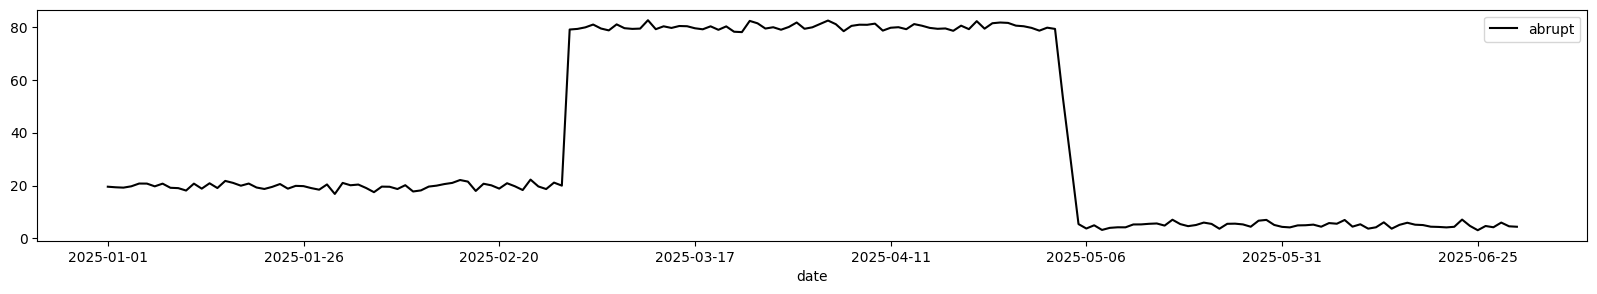

In [4]:
# Visualise the data
df.set_index('date').plot(figsize=(20,3), color='black')

## Detect Abrupt Trends (Default)

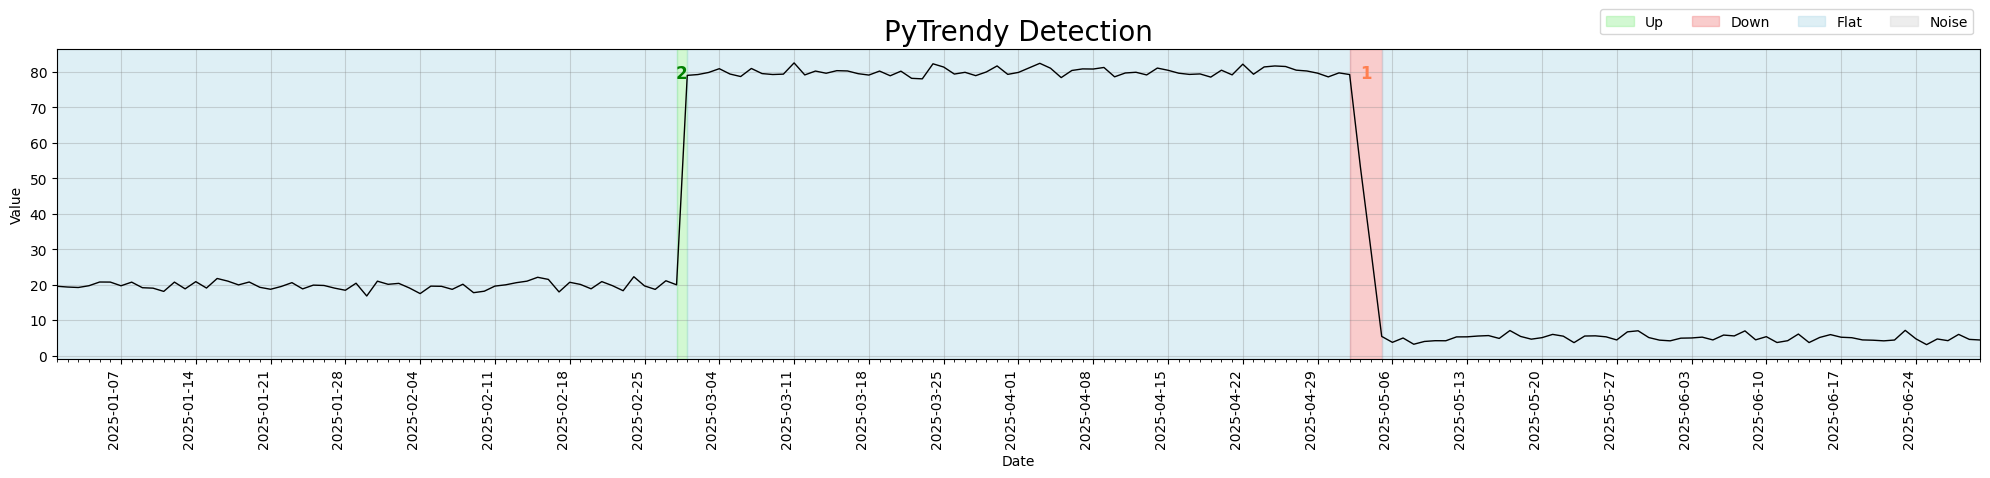

,direction,start,end,trend_class,pct_change,mltp_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,
2,Up,2025-02-28,2025-03-01,abrupt,2.953613,3.953613,1,59.029519,5.959392,2
4,Down,2025-05-02,2025-05-05,abrupt,-0.931331,0.068669,3,-73.804419,9.014544,1


In [5]:
# Detect and plot trends in the time series
results = pt.detect_trends(df, date_col='date', value_col='abrupt', plot=True)
results.filter_segments(direction='Up/Down')

- The uptrend has a total change of 59.02 over 1 day, while the downtrend has a total change of -73.80 over 3 days. 
- As a result, the downtrend has the higher change rank.

## Detect Abrupt Trends with Padding

You can also use padding to extend the detected segments to periods of persistent effects. This can be especially useful for applications such as Interrupted Time Series Analysis or Pre-Post Analysis.

You can enable padding via `method_params` and `abrupt_padding`:

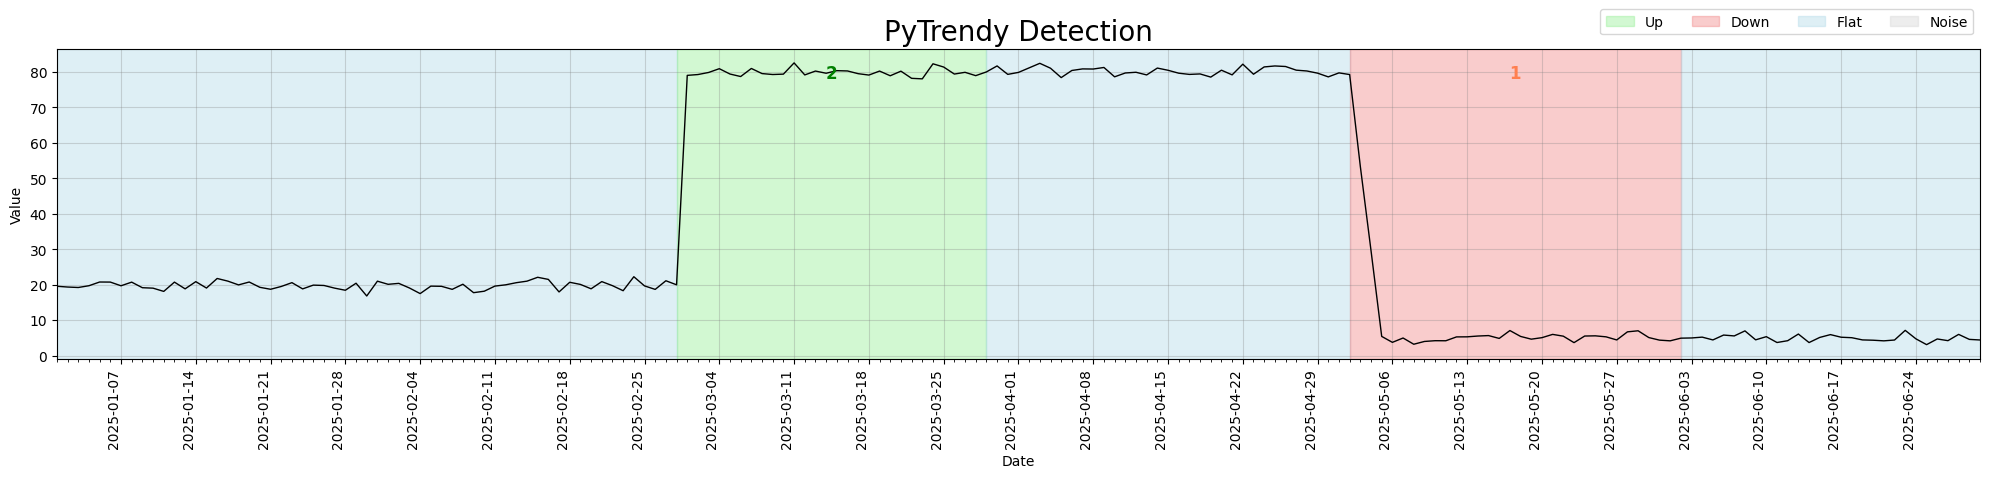

,direction,start,end,trend_class,padded,pct_change,mltp_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,,
2,Up,2025-02-28,2025-03-29,abrupt,True,3.002107,4.002107,29,59.998695,20.386664,2
4,Down,2025-05-02,2025-06-02,abrupt,True,-0.937571,0.062429,31,-74.298939,8.910108,1


In [6]:
results = pt.detect_trends(df
                            , date_col='date'
                            , value_col='abrupt'
                            , plot=True
                            , method_params=dict(abrupt_padding=28) # Specify padding in days. By default this is 0 (disabled).
                        )
results.filter_segments(direction='Up/Down')

By default the abrupt padding is 0 days. When modified you can explicitly set it to higher such as 28 days (4 weeks). This has changed the results:
- Uptrend has a total change of 59.99 over 29 days, and Downtrend has a total change of -74.29 over 31 days. 
- Total change isn't too different from previous results, since after the abrupt shifts, periods are flat. Their point effects randomly vary up and down around 0.

See what happens when you specify even longer, e.g. 168 days (6 months):

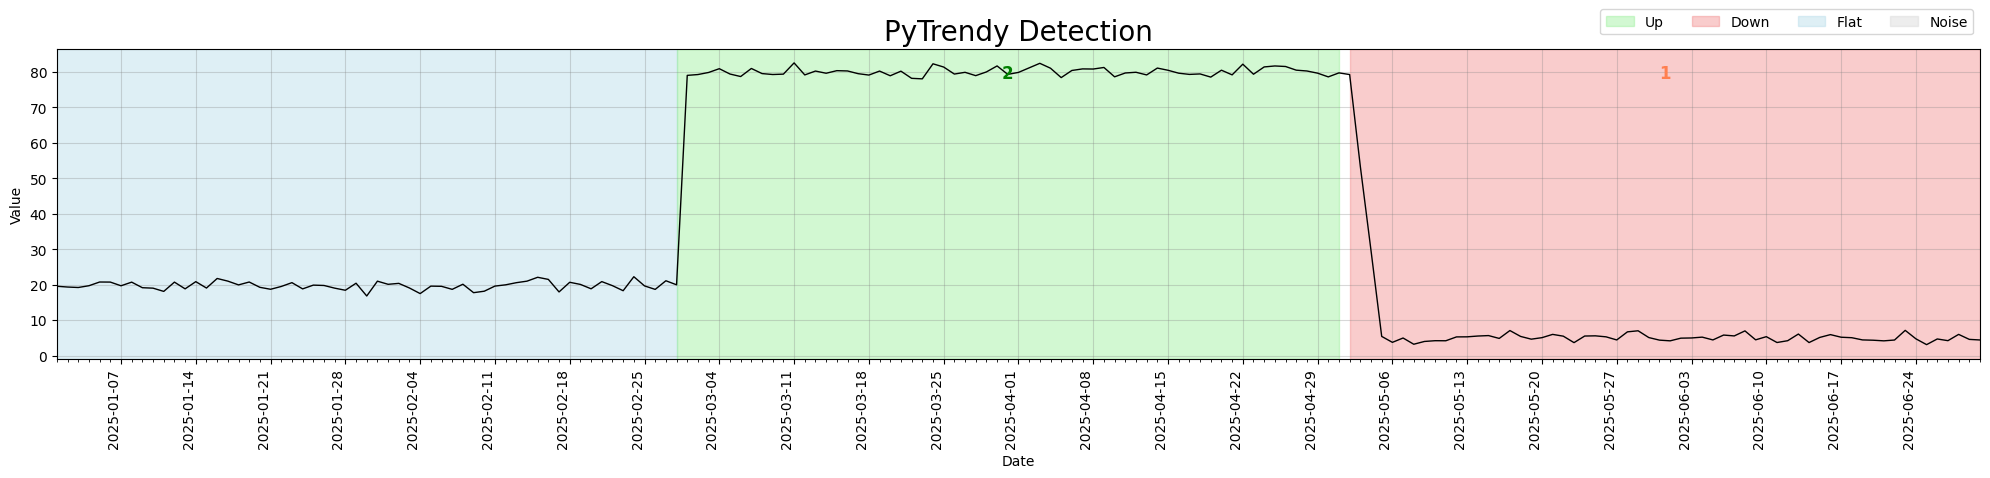

,direction,start,end,trend_class,padded,pct_change,mltp_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,,
2,Up,2025-02-28,2025-05-01,abrupt,True,2.988656,3.988656,62,59.729870,23.339405,2
3,Down,2025-05-02,2025-06-30,abrupt,True,-0.944034,0.055966,59,-74.811069,9.152818,1


In [7]:
results = pt.detect_trends(df
                            , date_col='date'
                            , value_col='abrupt'
                            , plot=True
                            , method_params=dict(abrupt_padding=168) # Specify padding of 6 months
                        )
results.filter_segments(direction='Up/Down')

Now the uptrend is padded all the way until a significant change in persistence is detected. As soon as the signal turns down, the up segment ends, even though 6 months was specified. The same applies to the downtrend, which is extended up until the final date in the dataset.

## Combining Abrupt and Gradual Trends

By design, both modes for detecting gradual and abrupt trends are enabled simultaneously. This allows you to detect both types of trends in the same time series.

Under the hood, PyTrendy makes use of Dynamic Time Warping (DTW) to achieve this. It first detects trends at a broad level with rolling window logic, and then classifies each as either abrupt or gradual with DTW. Based on their trend class, it then follows different post-processing logic to "refine" the trend segments.

In [8]:
# Loading both abrupt and gradual, combining them into the same dataframe

import pandas as pd

df = pt.load_data('series_synthetic')[['date', 'abrupt']]
temp_df = pt.load_data('series_synthetic')[['date', 'gradual']]

start, end = '2025-07-01', '2025-12-28'
temp_df.date = pd.date_range(start=start, end=end, freq='D')

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
temp_df = temp_df.set_index('date')

# Append rows by date, then sort
df = pd.concat([df, temp_df.rename(columns={'gradual': 'abrupt'})])
df = df.sort_index()
df = df.reset_index()

df = df.rename(columns={'abrupt': 'abrupt_then_gradual'})
df

,date,abrupt_then_gradual
0,2025-01-01,19.578066
1,2025-01-02,19.358378
2,2025-01-03,19.228408
3,2025-01-04,19.727130
4,2025-01-05,20.773716
...,...,...
357,2025-12-24,20.616883
358,2025-12-25,20.978084
359,2025-12-26,22.449495
360,2025-12-27,23.486652


<Axes: xlabel='date'>

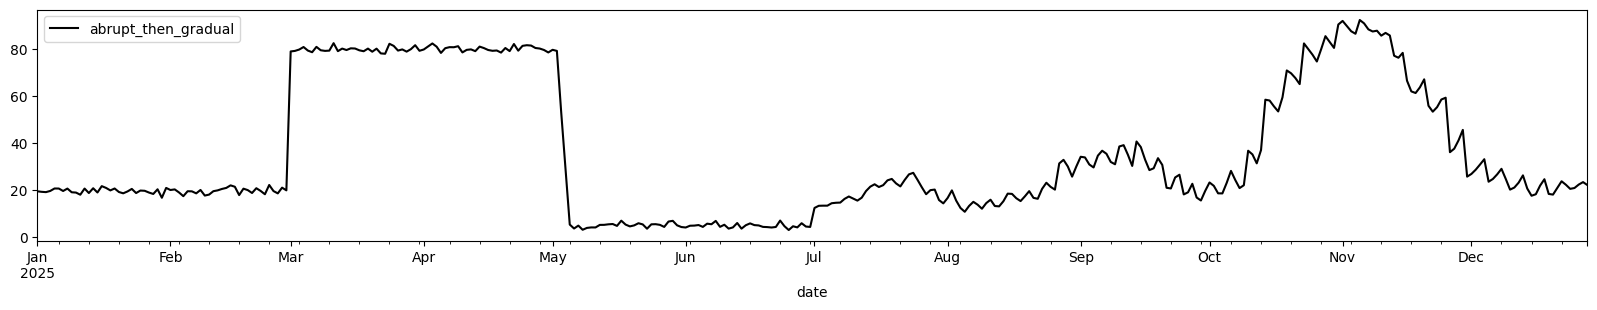

In [9]:
# Visualise the data
df.set_index('date').plot(figsize=(20,3), color='black')

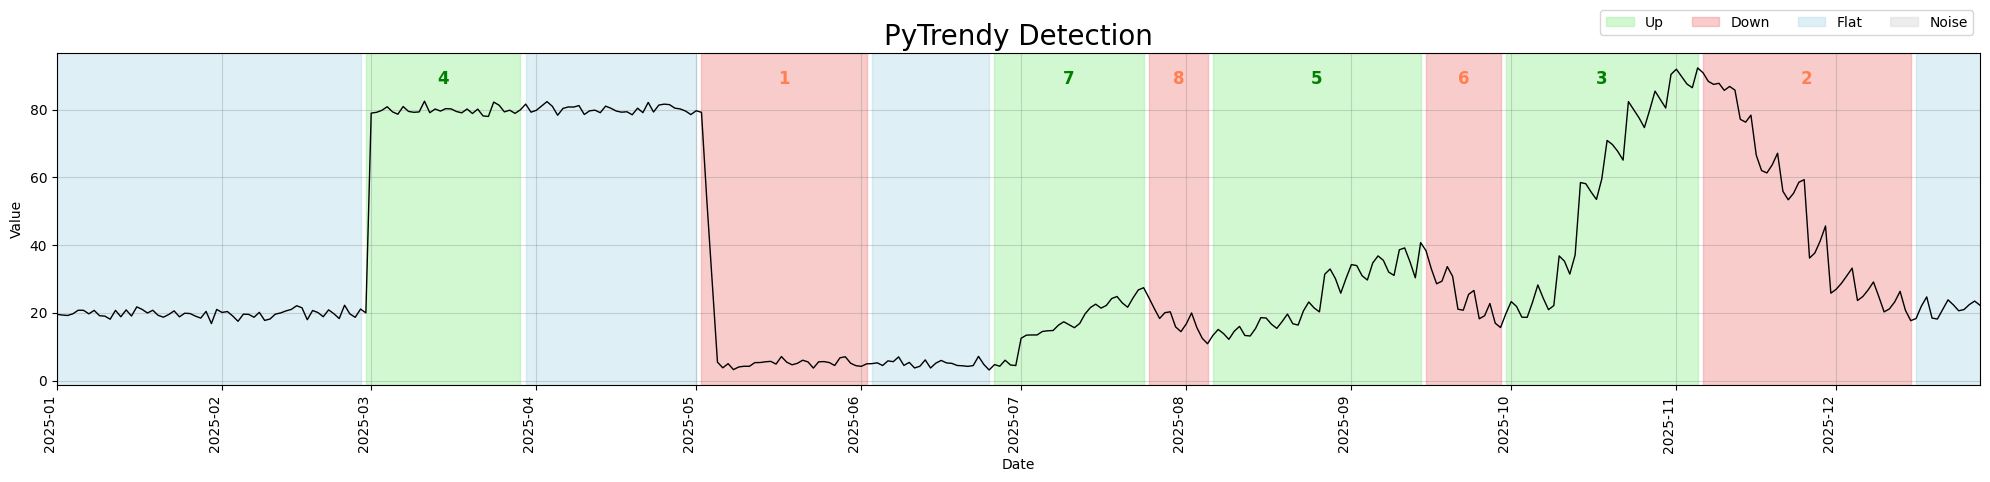

,direction,start,end,trend_class,padded,pct_change,mltp_change,days,total_change,SNR,change_rank
time_index,,,,,,,,,,,
2,Up,2025-02-28,2025-03-29,abrupt,True,3.002107,4.002107,29,59.998695,20.386664,4
4,Down,2025-05-02,2025-06-02,abrupt,True,-0.937571,0.062429,31,-74.298939,8.910108,1
6,Up,2025-06-26,2025-07-24,gradual,NaN,4.814085,5.814085,28,22.716340,19.989159,7
7,Down,2025-07-25,2025-08-05,gradual,NaN,-0.554982,0.445018,11,-13.564214,17.360657,8
8,Up,2025-08-06,2025-09-14,gradual,NaN,2.053528,3.053528,39,27.402597,18.645880,5
9,Down,2025-09-15,2025-09-29,gradual,NaN,-0.591909,0.408091,14,-22.721861,16.762790,6
10,Up,2025-09-30,2025-11-05,gradual,NaN,3.675005,4.675005,36,72.611833,21.701162,3
11,Down,2025-11-06,2025-12-15,gradual,NaN,-0.805442,0.194558,39,-73.253968,21.122099,2


In [10]:
results = pt.detect_trends(df
                            , date_col='date'
                            , value_col='abrupt_then_gradual'
                            , plot=True
                            , method_params=dict(abrupt_padding=28)
                        )
results.filter_segments(direction='Up/Down')

PyTrendy still correctly identifies the abrupt downtrend with the highest change rank. Following that is the steepest gradual downtrend, then the steepest uptrend.

Let's say, however, that I'm only interested in comparing the uptrends with each other. With `.filter_segments` you can limit the focus to that.

In [11]:
results = results.filter_segments(direction='Up', sort_by='change_rank') # order in desc by change rank
results

,direction,start,end,trend_class,pct_change,mltp_change,days,total_change,SNR,change_rank,padded
time_index,,,,,,,,,,,
10,Up,2025-09-30,2025-11-05,gradual,3.675005,4.675005,36,72.611833,21.701162,3,NaN
2,Up,2025-02-28,2025-03-29,abrupt,3.002107,4.002107,29,59.998695,20.386664,4,True
8,Up,2025-08-06,2025-09-14,gradual,2.053528,3.053528,39,27.402597,18.645880,5,NaN
6,Up,2025-06-26,2025-07-24,gradual,4.814085,5.814085,28,22.716340,19.989159,7,NaN


Since `sort_by='change_rank'` was specified, the results are already ordered from highest to lowest total change. If you want the rank column to reflect that ordering, you can re-compute it to take advantage of the new index.

In [12]:
results['change_rank'] = results.reset_index().index + 1 # update change rank to only be for uptrends
results

,direction,start,end,trend_class,pct_change,mltp_change,days,total_change,SNR,change_rank,padded
time_index,,,,,,,,,,,
10,Up,2025-09-30,2025-11-05,gradual,3.675005,4.675005,36,72.611833,21.701162,1,NaN
2,Up,2025-02-28,2025-03-29,abrupt,3.002107,4.002107,29,59.998695,20.386664,2,True
8,Up,2025-08-06,2025-09-14,gradual,2.053528,3.053528,39,27.402597,18.645880,3,NaN
6,Up,2025-06-26,2025-07-24,gradual,4.814085,5.814085,28,22.716340,19.989159,4,NaN


Now we clearly see the gradual uptrend as having the highest change rank, followed by the abrupt uptrend, then the second steepest gradual uptrend.

## Conclusion

PyTrendy provides a flexible toolkit for detecting both abrupt and gradual trends. In this notebook, we demonstrated how to:

- Detect abrupt trends and analyze their magnitude and duration.
- Apply padding to capture persistent effects after abrupt changes.
- Combine abrupt and gradual trends into a single analysis.